# 1. Data Preparation – Tmin Peru Raster
  
**Repositorio:** `Minimum-Temperature-Raster`  
**Objetivo:** Preparar los insumos base (raster y shapefile) para el análisis de temperaturas mínimas (Tmin) del Perú.  

---

### Propósito

1. Cargar y limpiar los límites administrativos (departamentos, provincias o distritos).  
2. Asegurar que los campos `NOMBRE`/`UBIGEO` estén **en mayúsculas** y **sin tildes**.  
3. Cargar el raster GeoTIFF de **temperatura mínima (Tmin)** y verificar su estructura.  
4. Preparar un bucle para iterar sobre las bandas (asumiendo Band 1 = año 2020, etc.).  


**Importar librerías**

In [8]:
#En Anaconda Prompt
#pip install -r requirements.txt
#!pip install unidecode

In [9]:
import geopandas as gpd
import rasterio
import rioxarray 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
from rasterio.plot import show
import os

## 1.1 Cargar shapefile de límites administrativos

En este paso cargamos el shapefile del Perú (departamentos, provincias o distritos).  
Usamos rutas **relativas** (`data/raw/`) para asegurar reproducibilidad.

Tenemos carpetas: district, province, department.

In [10]:
# Mostrar el directorio de trabajo actual
print(os.getcwd())


C:\Users\KikeMa\Documents\Azu\diplomado\Tarea\Minimum-Temperature-Raster


In [11]:
# Cambiar el directorio
os.chdir("C:/Users/KikeMa/Documents/Azu/diplomado/Tarea/Minimum-Temperature-Raster")

In [12]:
import geopandas as gpd
import os

# Definir rutas relativas
base_path = "data/raw"

# Rutas a cada nivel administrativo
shp_department = os.path.join(base_path, "department", "Departamental INEI 2023 geogpsperu SuyoPomalia.shp")
shp_province   = os.path.join(base_path, "province", "Provincial INEI 2023 geogpsperu SuyoPomalia.shp")
shp_district   = os.path.join(base_path, "district", "Distrital INEI 2023 geogpsperu SuyoPomalia.shp")

#Cargar shapefiles
dept = gpd.read_file(shp_department)
prov = gpd.read_file(shp_province)
dist = gpd.read_file(shp_district)


## 1.2 Limpieza de campos: nombres y acentos

Comprobamos que todos los nombres de columnas esten en mayúsculas y eliminamos los acentos o tildes de los nombres geográficos.  
Esto evita errores al hacer merges o zonal statistics.


**A.** Limpieza por departamento

In [13]:
# Mostrar una vista previa de las columnas clave
dept.head(3)

,CCDD,DEPARTAMEN,OBJECTID,ESRI_OID,geometry
0,01,AMAZONAS,1.0,1.0,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995..."
1,02,ANCASH,2.0,2.0,"POLYGON ((-77.64697 -8.05086, -77.64689 -8.051..."
2,03,APURIMAC,3.0,3.0,"POLYGON ((-73.74655 -13.17442, -73.7457 -13.17..."


In [14]:

# Renombrar columnas a formato estándar en mayúsculas
dept = dept.rename(columns={
    'CDD': 'CCDD',
    'DEPARTAMEN': 'DEPARTAMENTO'})

# Eliminar columnas innecesarias
dept = dept.drop(columns=['OBJECTID', 'ESRI_OID'], errors='ignore')

# Asegurar tipo de dato correcto para el código (como string de 2 dígitos)
dept['CCDD'] = dept['CCDD'].astype(str).str.zfill(2)

# Normalizar nombres de departamento (en mayúsculas y sin espacios)
dept['DEPARTAMENTO'] = dept['DEPARTAMENTO'].str.strip().str.upper()

# Verificar resultado
dept.head(3)


,CCDD,DEPARTAMENTO,geometry
0,01,AMAZONAS,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995..."
1,02,ANCASH,"POLYGON ((-77.64697 -8.05086, -77.64689 -8.051..."
2,03,APURIMAC,"POLYGON ((-73.74655 -13.17442, -73.7457 -13.17..."


**B.** Limpieza Provincia

In [15]:
# Mostrar una vista previa de las columnas clave
prov.head(3)

,OBJECTID,CCDD,CCPP,DEPARTAMEN,PROVINCIA,geometry
0,1.0,01,01,AMAZONAS,CHACHAPOYAS,"POLYGON ((-77.72614 -5.94354, -77.72486 -5.943..."
1,2.0,01,02,AMAZONAS,BAGUA,"POLYGON ((-78.61909 -4.51001, -78.61802 -4.510..."
2,3.0,01,03,AMAZONAS,BONGARA,"POLYGON ((-77.72759 -5.1403, -77.72361 -5.1406..."


In [16]:
prov.columns

Index(['OBJECTID', 'CCDD', 'CCPP', 'DEPARTAMEN', 'PROVINCIA', 'geometry'], dtype='object')

In [17]:
from unidecode import unidecode

# Normalizar nombres de columnas
prov.columns = prov.columns.str.strip().str.upper()

# Asegurar consistencia en nombres de departamentos y provincias
prov['DEPARTAMEN'] = prov['DEPARTAMEN'].apply(lambda x: unidecode(x.strip().upper()))
prov['PROVINCIA'] = prov['PROVINCIA'].apply(lambda x: unidecode(x.strip().upper()))

# Eliminar columnas innecesarias
prov = prov.drop(columns=['OBJECTID'], errors='ignore')

# Eliminar posibles duplicados
prov = prov.drop_duplicates(subset=['CCDD', 'CCPP']).reset_index(drop=True)

# Verificar 
prov.head(5)


,CCDD,CCPP,DEPARTAMEN,PROVINCIA,GEOMETRY
0,01,01,AMAZONAS,CHACHAPOYAS,"POLYGON ((-77.72614 -5.94354, -77.72486 -5.943..."
1,01,02,AMAZONAS,BAGUA,"POLYGON ((-78.61909 -4.51001, -78.61802 -4.510..."
2,01,03,AMAZONAS,BONGARA,"POLYGON ((-77.72759 -5.1403, -77.72361 -5.1406..."
3,01,04,AMAZONAS,CONDORCANQUI,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995..."
4,01,05,AMAZONAS,LUYA,"POLYGON ((-78.13023 -5.9037, -78.13011 -5.9041..."


**C.** Limpieza distrito

In [18]:
# Mostrar una vista previa de las columnas clave
dist.head(3)

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,geometry
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846..."
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945..."
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909..."


In [19]:
# Normalizar nombres de columnas
dist.columns = dist.columns.str.strip().str.upper()

# Asegurar consistencia en nombres
for col in ['DEPARTAMEN', 'PROVINCIA', 'DISTRITO']:
    dist[col] = dist[col].apply(lambda x: unidecode(x.strip().upper()))

dist.head(3)

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,GEOMETRY
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846..."
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945..."
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909..."


## 1.3. Verificar y ajustar el sistema de coordenadas (CRS)

Todos los datos deben estar en el sistema de referencia **EPSG:4326 (WGS 84)**  
para que coincidan con el raster y sean compatibles con Streamlit Maps.  


In [20]:
import geopandas as gpd

# Asegurar que GEOMETRY sea la geometría activa
dist = dist.set_geometry("GEOMETRY")

# Verificar CRS
print("CRS actual:", dist.crs)



CRS actual: EPSG:4326


Guardar shapefiles

In [21]:
# Guardar shapefiles reproyectados
dept.to_file("data/processed/departamentos.shp", driver="ESRI Shapefile", encoding="utf-8")
prov.to_file("data/processed/provincias.shp", driver="ESRI Shapefile", encoding="utf-8")
dist.to_file("data/processed/distritos.shp", driver="ESRI Shapefile", encoding="utf-8")

C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\936908139.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  dept.to_file("data/processed/departamentos.shp", driver="ESRI Shapefile", encoding="utf-8")
C:\Users\KikeMa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'DEPARTAMENTO' to 'DEPARTAMEN'
  ogr_write(


## 1.5. Cargar y explorar el raster Tmin

Abrimos el raster GeoTIFF (`tmin_raster.tif`), verificamos:
- Número de bandas (puede representar años o meses)
- CRS (debe ser el mismo que el shapefile)
- Resolución espacial y extensión


In [22]:
# Cargar raster (ruta relativa desde notebooks/)
raster_path = "./data/raw/tmin_raster.tif"

raster = rasterio.open(raster_path)

print("Raster cargado correctamente")
print(f"Bandas: {raster.count}")
print(f"CRS: {raster.crs}")
print(f"Resolución: {raster.res}")
print(f"Límites: {raster.bounds}")


Raster cargado correctamente
Bandas: 5
CRS: EPSG:4326
Resolución: (0.04999999999999716, 0.050000000000000044)
Límites: BoundingBox(left=-81.38, bottom=-18.65000000000002, right=-67.1300000000008, top=1.2000000000000002)


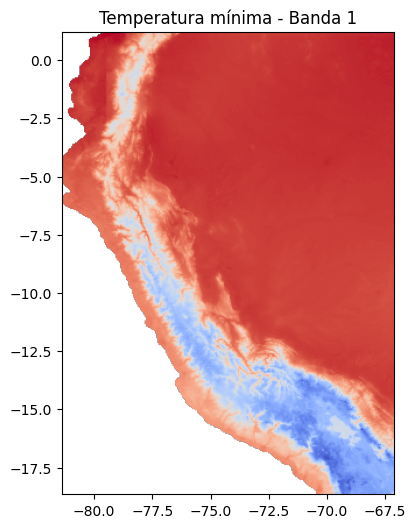

Banda 1: min=nan, max=nan, mean=nan
Banda 2: min=nan, max=nan, mean=nan
Banda 3: min=nan, max=nan, mean=nan
Banda 4: min=nan, max=nan, mean=nan
Banda 5: min=nan, max=nan, mean=nan


In [23]:
# Visualizar una banda (por ejemplo, la primera)
import matplotlib.pyplot as plt
from rasterio.plot import show

fig, ax = plt.subplots(figsize=(6, 6))
show(raster, 1, ax=ax, cmap="coolwarm")
ax.set_title("Temperatura mínima - Banda 1")
plt.show()

# Información de todas las bandas
for i in range(1, raster.count + 1):
    band = raster.read(i)
    print(f"Banda {i}: min={band.min():.2f}, max={band.max():.2f}, mean={band.mean():.2f}")


**Cargar el raster con rioxarray y asignar nombres a las bandas (2020–2024)**

In [24]:
import rioxarray

# Cargar el raster con rioxarray (mantiene metadatos geoespaciales)
tmin = rioxarray.open_rasterio("./data/raw/tmin_raster.tif", masked=True)

# Revisar la estructura del objeto
print(tmin)

# Asignar nombres de banda según los años
años = [2020, 2021, 2022, 2023, 2024]
tmin = tmin.assign_coords(band=años)

print("\n Bandas renombradas:")
print(tmin.band.values)




<xarray.DataArray (band: 5, y: 397, x: 285)> Size: 2MB
[565725 values with dtype=float32]
Coordinates:
  * band         (band) int64 40B 1 2 3 4 5
  * y            (y) float64 3kB 1.175 1.125 1.075 ... -18.53 -18.58 -18.63
  * x            (x) float64 2kB -81.35 -81.3 -81.25 ... -67.26 -67.21 -67.16
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

 Bandas renombradas:
[2020 2021 2022 2023 2024]


In [25]:
# Ver un resumen estadístico general
print("\n Estadísticas descriptivas por año:")
for año in tmin.band.values:
    datos = tmin.sel(band=año)
    print(f"Año {año}: min={float(datos.min()):.2f}, max={float(datos.max()):.2f}, mean={float(datos.mean()):.2f}")


 Estadísticas descriptivas por año:
Año 2020: min=-9.05, max=24.64, mean=18.01
Año 2021: min=-10.02, max=24.39, mean=17.91
Año 2022: min=-9.87, max=24.21, mean=17.77
Año 2023: min=-9.06, max=24.12, mean=17.61
Año 2024: min=-8.85, max=24.15, mean=17.82


# 2. Cálculo de Estadísticas Zonales del Ráster

## 2.1 Extracción de métricas a nivel distrital

In [26]:
dist.head(5)

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,GEOMETRY
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846..."
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945..."
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909..."
3,010104,01,01,04,AMAZONAS,CHACHAPOYAS,CHETO,4.0,4.0,"POLYGON ((-77.71486 -6.24598, -77.71485 -6.245..."
4,010105,01,01,05,AMAZONAS,CHACHAPOYAS,CHILIQUIN,5.0,5.0,"POLYGON ((-77.77405 -5.99598, -77.77328 -5.996..."


## 2.2. Importamos shapefile procesado

In [27]:
import geopandas as gpd
from rasterstats import zonal_stats
import pandas as pd
from shapely.geometry import box
import numpy as np
import pandas as pd


# Ruta a shapefile procesado
shp_path = "./data/processed/distritos.shp"

# Cargar shapefile
dist = gpd.read_file(shp_path) 

## 2.3. Cálculo de indicadores

In [28]:
# helpers seguros 
def _vals_clean(x):
    mx = np.ma.asarray(x)
    v  = mx.compressed()                      # quita máscara -> 1D
    if v.size == 0:
        return np.array([], dtype=float)
    v = np.array(v, dtype=float, copy=True)   # copia = writable
    v = v[np.isfinite(v)]                     # sin NaN/Inf
    return v

def p10_safe(x):
    v = _vals_clean(x)
    return np.nan if v.size == 0 else np.nanpercentile(v, 10)

def p90_safe(x):
    v = _vals_clean(x)
    return np.nan if v.size == 0 else np.nanpercentile(v, 90)

def amplitud_safe(x):
    v = _vals_clean(x)
    return np.nan if v.size == 0 else (np.nanmax(v) - np.nanmin(v))
dist_in = dist

anios_dist = [2020, 2021, 2022, 2023, 2024]
estadisticos_dist = ["count", "mean", "min", "max", "std", "median",
                     "percentile_10", "percentile_90", "amplitud"]
acum_dist = {stat: [] for stat in estadisticos_dist}

for año in anios_dist:
    stats_dist = zonal_stats(
        dist_in,
        "./data/raw/tmin_raster.tif",
        stats=["count", "mean", "min", "max", "std", "median"],
        add_stats={
            "percentile_10": p10_safe,
            "percentile_90": p90_safe,
            "amplitud":      amplitud_safe,
        },
        band=(año - 2019),
        geojson_out=False,
        nodata=None,          # si tu TIFF tiene NODATA, ponlo aquí (ej. -9999)
        all_touched=False
    )
    df_dist = pd.DataFrame(stats_dist)
    for stat in estadisticos_dist:
        if stat in df_dist.columns:
            acum_dist[stat].append(df_dist[stat].to_numpy())

# Promedios 2020–2024 por estadístico; se agregan a dist_in
for stat, listas in acum_dist.items():
    if len(listas) == len(anios_dist) and len(listas) > 0:
        arr = np.vstack(listas)                 # (5, n_distritos_validos)
        dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)

# Vuelca a 'dist' (alineación por índice; donde no intersecta queda NaN)
for col in dist_in.columns:
    if col.startswith("tmin_") and col.endswith("_total"):
        dist[col] = dist_in[col]

cols_totales_dist = [c for c in dist.columns if c.startswith("tmin_") and c.endswith("_total")]
print("Columnas totales creadas:", cols_totales_dist)
print(dist[["DISTRITO"] + cols_totales_dist].head())


C:\Users\KikeMa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rasterstats\io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


Columnas totales creadas: ['tmin_count_total', 'tmin_mean_total', 'tmin_min_total', 'tmin_max_total', 'tmin_std_total', 'tmin_median_total', 'tmin_percentile_10_total', 'tmin_percentile_90_total', 'tmin_amplitud_total']
      DISTRITO  tmin_count_total  tmin_mean_total  tmin_min_total  \
0  CHACHAPOYAS               6.0        12.403868       11.032648   
1     ASUNCION               2.0        10.232676       10.029134   
2       BALSAS              11.0        14.492733        9.164226   
3        CHETO               3.0        11.770264       11.627967   
4    CHILIQUIN               5.0        11.065167        9.423780   

   tmin_max_total  tmin_std_total  tmin_median_total  \
0       13.120787        0.744316          12.742976   
1       10.436218        0.203542          10.232676   
2       18.931234        3.263794          15.668368   
3       11.850517        0.100983          11.832309   
4       12.711129        1.117485          10.918611   

   tmin_percentile_10_total 

C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\3116635581.py:53: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\3116635581.py:53: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\3116635581.py:53: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\3116635581.py:53: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\3116635581.py:53: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\3116635581.py:53: RuntimeWarning: Mean of empty slice
  dist_in[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)
C:\Users\KikeMa\AppDat

In [29]:
dist.head(5)

,UBIGEO,CCDD,CCPP,CCDI,DEPARTAMEN,PROVINCIA,DISTRITO,OBJECTID,ESRI_OID,geometry,tmin_count_total,tmin_mean_total,tmin_min_total,tmin_max_total,tmin_std_total,tmin_median_total,tmin_percentile_10_total,tmin_percentile_90_total,tmin_amplitud_total
0,010101,01,01,01,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1.0,1.0,"POLYGON ((-77.8858 -6.1778, -77.88323 -6.17846...",6.0,12.403868,11.032648,13.120787,0.744316,12.742976,11.418373,13.050255,2.088139
1,010102,01,01,02,AMAZONAS,CHACHAPOYAS,ASUNCION,2.0,2.0,"POLYGON ((-77.74482 -5.94497, -77.74482 -5.945...",2.0,10.232676,10.029134,10.436218,0.203542,10.232676,10.069842,10.395510,0.407085
2,010103,01,01,03,AMAZONAS,CHACHAPOYAS,BALSAS,3.0,3.0,"POLYGON ((-77.9358 -6.69039, -77.93531 -6.6909...",11.0,14.492733,9.164226,18.931234,3.263794,15.668368,10.584344,18.079209,9.767008
3,010104,01,01,04,AMAZONAS,CHACHAPOYAS,CHETO,4.0,4.0,"POLYGON ((-77.71486 -6.24598, -77.71485 -6.245...",3.0,11.770264,11.627967,11.850517,0.100983,11.832309,11.668836,11.846875,0.222549
4,010105,01,01,05,AMAZONAS,CHACHAPOYAS,CHILIQUIN,5.0,5.0,"POLYGON ((-77.77405 -5.99598, -77.77328 -5.996...",5.0,11.065167,9.423780,12.711129,1.117485,10.918611,9.854567,12.335305,3.287350


## 2.4. Exportación de resultados

In [30]:
import os

# Definimos las columnas que deseas exportar (solo las totales)
cols_export = ["UBIGEO", "DEPARTAMEN", "PROVINCIA", "DISTRITO"] + \
              [col for col in dist.columns if col.startswith("tmin_") and col.endswith("_total")]

# Exportamos a CSV (datos tabulares)
csv_path = "./data/processed/tmin_zonal_stats_distritos.csv"
dist[cols_export].to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"Archivo CSV exportado correctamente:\n{csv_path}")

# Exportamos a GeoJSON (para visualización geoespacial)
geojson_path = "./data/processed/tmin_zonal_stats_distritos.geojson"
dist[cols_export + ["geometry"]].to_file(geojson_path, driver="GeoJSON", encoding="utf-8")
print(f"Archivo GeoJSON exportado correctamente:\n{geojson_path}")


Archivo CSV exportado correctamente:
./data/processed/tmin_zonal_stats_distritos.csv
Archivo GeoJSON exportado correctamente:
./data/processed/tmin_zonal_stats_distritos.geojson


## 2.5 Visualizamos la temperatura minima promedio en el mapa de distritos del Perú

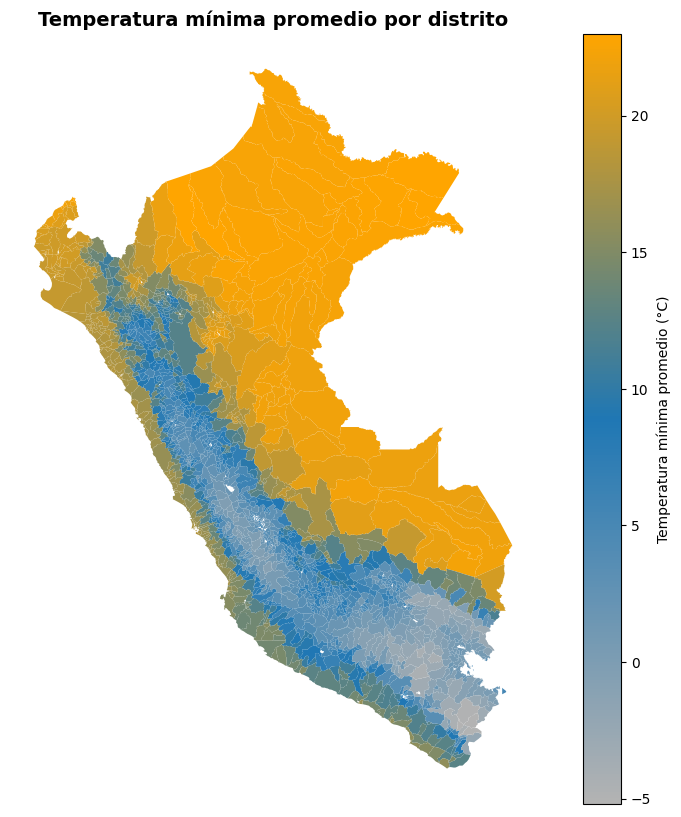


Columnas disponibles en el dataframe:
['UBIGEO', 'CCDD', 'CCPP', 'CCDI', 'DEPARTAMEN', 'PROVINCIA', 'DISTRITO', 'OBJECTID', 'ESRI_OID', 'geometry', 'tmin_count_total', 'tmin_mean_total', 'tmin_min_total', 'tmin_max_total', 'tmin_std_total', 'tmin_median_total', 'tmin_percentile_10_total', 'tmin_percentile_90_total', 'tmin_amplitud_total']


In [31]:
# Visualizar los resultados en un mapa
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

colors = ["#b3b3b3", "#1f77b4", "#ffa500"]  # gris → azul → anaranjado
cmap_custom = LinearSegmentedColormap.from_list("FrioAzulNaranja", colors, N=256)

# Graficamos el mapa
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
dist.plot(
    column="tmin_mean_total",
    ax=ax,
    legend=True,
    cmap=cmap_custom,
    legend_kwds={
        'label': "Temperatura mínima promedio (°C)",
        'orientation': 'vertical'
    }
)
ax.set_title("Temperatura mínima promedio por distrito", fontsize=14, fontweight="bold")
ax.axis("off")
plt.show()

print("\nColumnas disponibles en el dataframe:")
print(dist.columns.tolist())

## 2.6. Validación y control de calidad (histogramas de distribución de temperaturas y detección de valores)

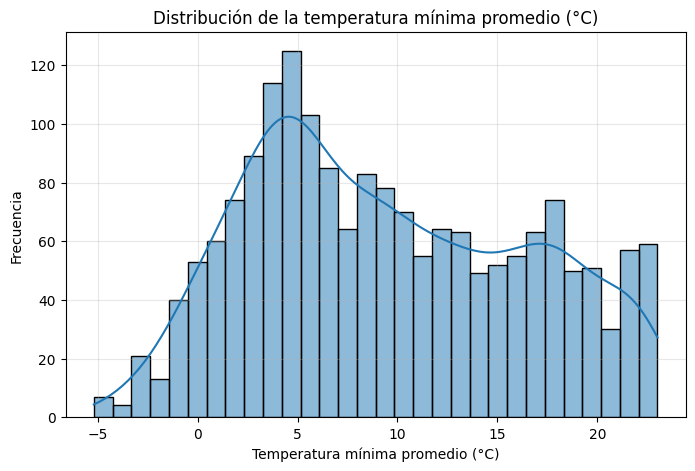

In [32]:
# a. Histograma de la distribucion de la temperatura mínima promedio (C)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(dist["tmin_mean_total"], bins=30, kde=True, color="#1f77b4")
plt.title("Distribución de la temperatura mínima promedio (°C)")
plt.xlabel("Temperatura mínima promedio (°C)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()

#### El histograma representa la distribución de las temperaturas mínimas promedio registradas entre 2020 y 2024, calculadas a nivel distrital.

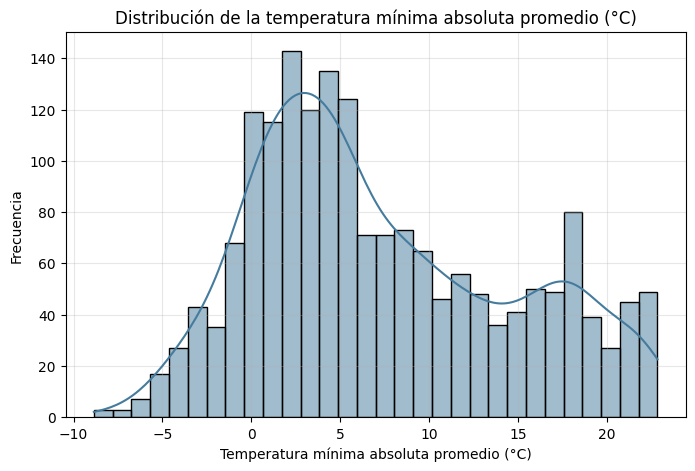

In [33]:
# b. Histograma de la distribución de la temperatura mínima absoluta promedio  (C)

plt.figure(figsize=(8, 5))
sns.histplot(dist["tmin_min_total"], bins=30, kde=True, color="#457b9d")
plt.title("Distribución de la temperatura mínima absoluta promedio (°C)")
plt.xlabel("Temperatura mínima absoluta promedio (°C)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()


#### Este histograma muestra cómo se distribuyen las temperaturas mínimas absolutas promedio en los distritos del Perú (2020–2024). La mayoría de los distritos deberían concentrarse en torno a los valores fríos (entre 5 °C y 15 °C), mientras que los valores extremos hacia la izquierda representan zonas altoandinas con temperaturas bajo cero.

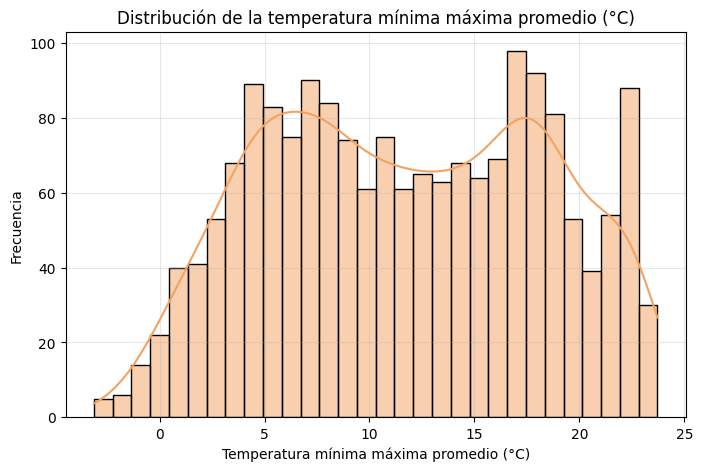

In [34]:
# c. Distribución de la temperatura mínima máxima promedio
plt.figure(figsize=(8, 5))
sns.histplot(dist["tmin_max_total"], bins=30, kde=True, color="#f4a261")
plt.title("Distribución de la temperatura mínima máxima promedio (°C)")
plt.xlabel("Temperatura mínima máxima promedio (°C)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show() 


##### Este gráfico representa los valores más altos dentro de las temperaturas mínimas promedio por distrito (2020–2024). Los distritos con valores más altos (hacia la derecha del histograma) suelen corresponder a zonas costeras o amazónicas, donde las noches son más cálidas. Los valores más bajos (hacia la izquierda) indican mayor altitud y riesgo de heladas.

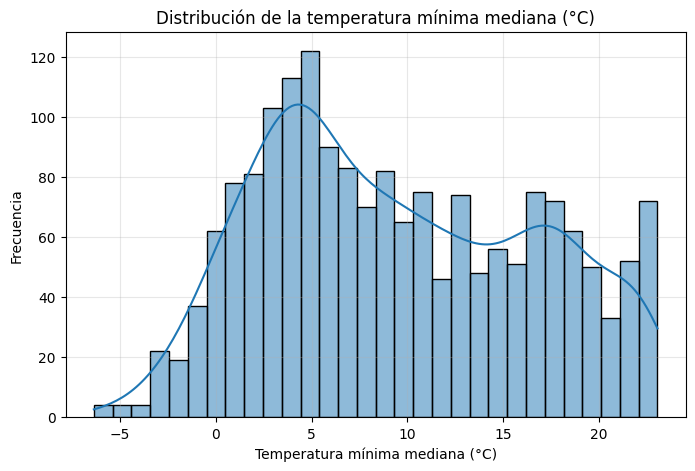

In [35]:
# d. Distribución de la temperatura mínima mediana

plt.figure(figsize=(8, 5))
sns.histplot(dist["tmin_median_total"], bins=30, kde=True, color="#1f77b4")
plt.title("Distribución de la temperatura mínima mediana (°C)")
plt.xlabel("Temperatura mínima mediana (°C)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()

#### La temperatura mínima mediana representa el valor central de la distribución de temperaturas mínimas observadas en cada distrito durante el periodo 2020–2024.

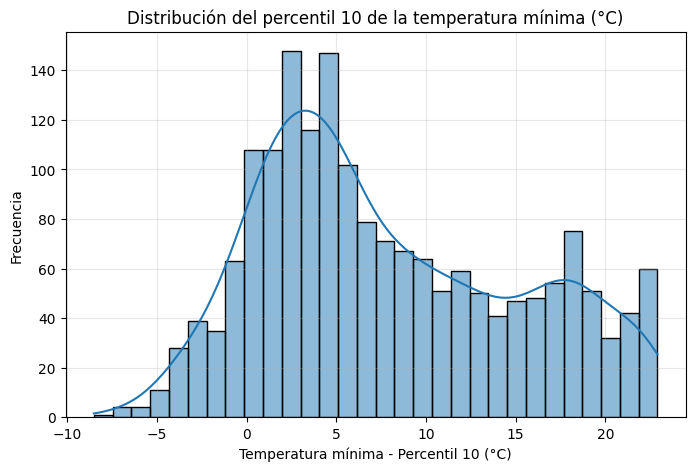

In [36]:
# e. Distribución del percentil 10 de la temperatura mínima

plt.figure(figsize=(8, 5))
sns.histplot(dist["tmin_percentile_10_total"], bins=30, kde=True, color="#1f77b4")
plt.title("Distribución del percentil 10 de la temperatura mínima (°C)")
plt.xlabel("Temperatura mínima - Percentil 10 (°C)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()


#### Este gráfico muestra la distribución del percentil 10 de la temperatura mínima promedio en los distritos del Perú (2020–2024). Representa los valores fríos más frecuentes (es decir, el límite inferior del 10 % de temperaturas mínimas).

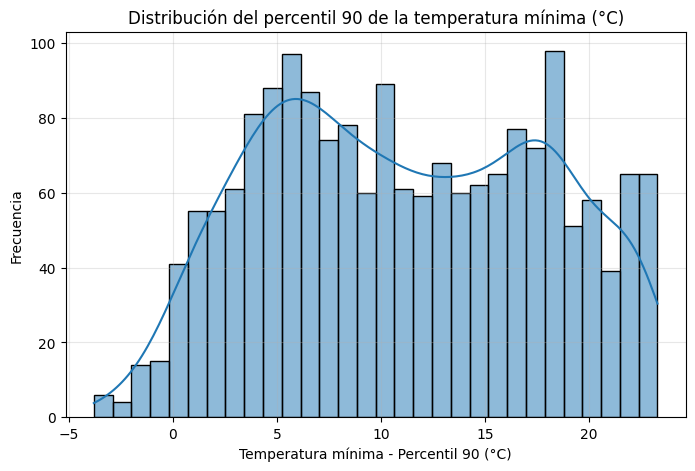

In [37]:
#### f. Distribución del percentil 90 de la temperatura mínima
plt.figure(figsize=(8, 5))
sns.histplot(dist["tmin_percentile_90_total"], bins=30, kde=True, color="#1f77b4")
plt.title("Distribución del percentil 90 de la temperatura mínima (°C)")
plt.xlabel("Temperatura mínima - Percentil 90 (°C)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()


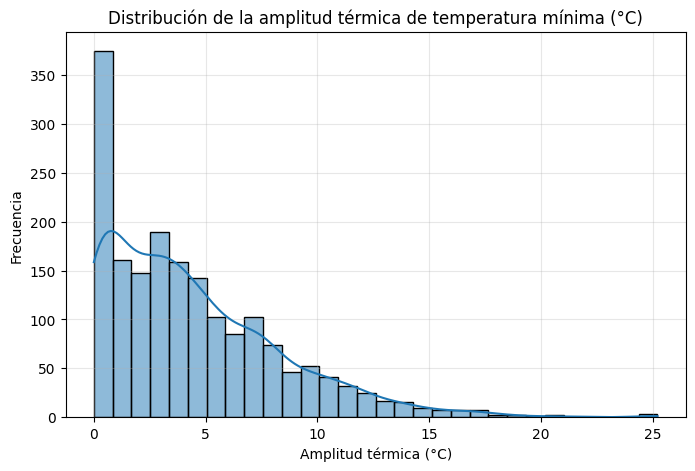

In [38]:
## g. Distribución de la amplitud térmica de temperatura mínima

plt.figure(figsize=(8, 5))
sns.histplot(dist["tmin_amplitud_total"], bins=30, kde=True, color="#1f77b4")
plt.title("Distribución de la amplitud térmica de temperatura mínima (°C)")
plt.xlabel("Amplitud térmica (°C)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()


In [39]:
# h. Verificar valores nulos en las columnas de temperatura mínima
cols_tmin = [col for col in dist.columns if col.startswith("tmin_") and col.endswith("_total")]

# Calcular número y porcentaje de nulos
nulos = dist[cols_tmin].isna().sum().sort_values(ascending=False)
porc_nulos = (nulos / len(dist)) * 100

# Creamos un DataFrame resumen
nulos_df = pd.DataFrame({
    "Nulos": nulos,
    "Porcentaje (%)": porc_nulos.round(2)
})

print("Valores nulos por variable:")
display(nulos_df)


Valores nulos por variable:


,Nulos,Porcentaje (%)
tmin_mean_total,86,4.55
tmin_median_total,86,4.55
tmin_min_total,86,4.55
tmin_max_total,86,4.55
tmin_std_total,86,4.55
tmin_percentile_90_total,86,4.55
tmin_percentile_10_total,86,4.55
tmin_amplitud_total,86,4.55
tmin_count_total,0,0.00


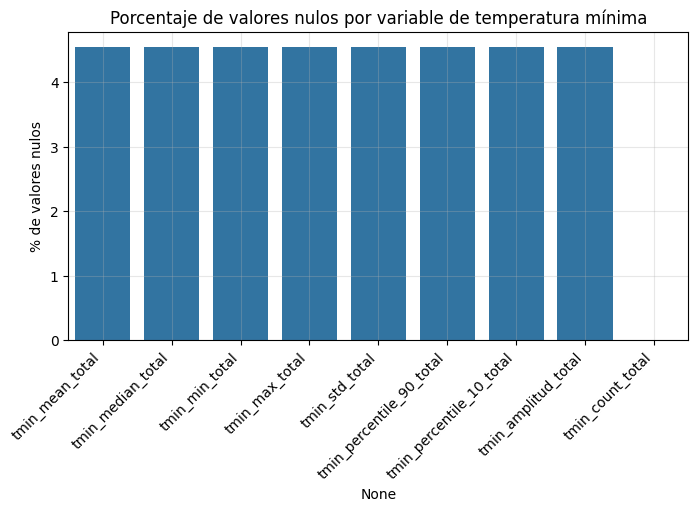

In [40]:
#i. Porcentaje de valores nulos por variable de temperatura mínima

plt.figure(figsize=(8, 4))
sns.barplot(x=nulos_df.index, y=nulos_df["Porcentaje (%)"], color="#1f77b4")
plt.title("Porcentaje de valores nulos por variable de temperatura mínima")
plt.xticks(rotation=45, ha="right")
plt.ylabel("% de valores nulos")
plt.grid(alpha=0.3)
plt.show()


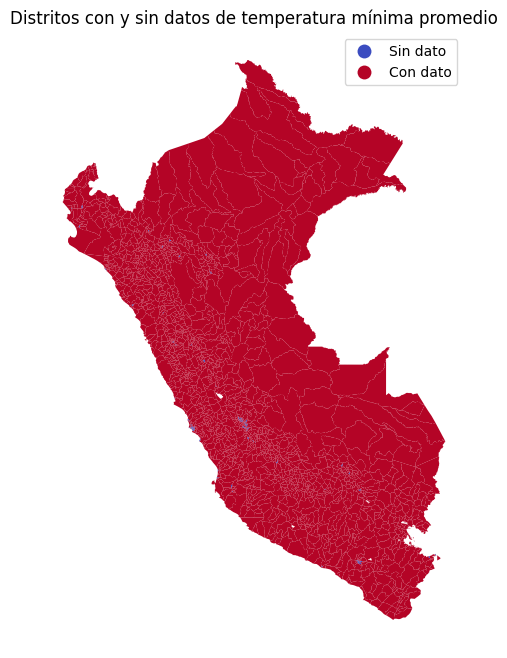

In [41]:
# j. Distritos con y sin datos de temperatura mínima promedio

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
dist["tiene_dato"] = ~dist["tmin_mean_total"].isna()
dist.plot(
    column="tiene_dato",
    categorical=True,
    cmap="coolwarm",
    legend=True,
    ax=ax,
    legend_kwds={'labels': ['Sin dato', 'Con dato']}
)
ax.set_title("Distritos con y sin datos de temperatura mínima promedio")
ax.axis("off")
plt.show()

#### La amplitud térmica representa la diferencia entre el valor máximo y el mínimo de las temperaturas mínimas promedio durante el período 2020–2024. Valores altos indican distritos con mayor variabilidad térmica nocturna

## 2.7. (opcional) estaditicos por regiones 

In [42]:
import geopandas as gpd
from rasterstats import zonal_stats
import pandas as pd

# Ruta a shapefile procesado
shp_path = "./data/processed/departamentos.shp"

# Cargar shapefile
dept = gpd.read_file(shp_path) 

In [43]:
# Años/bandas del ráster
anios = [2020, 2021, 2022, 2023, 2024]

# Estadísticos a calcular (incluye amplitud = max - min)
estadisticos = ["count", "mean", "min", "max", "std", "median", "percentile_10", "percentile_90", "amplitud"]

# Acumulador: por cada estadístico, una lista de arrays (uno por año)
acum = {stat: [] for stat in estadisticos}

# Loop por año (NO creamos columnas por año)
for año in anios:
    stats = zonal_stats(
        dept,
        "./data/raw/tmin_raster.tif",
        stats=["count", "mean", "min", "max", "std", "median"],   # base
        add_stats={
            "percentile_10": lambda x: np.nanpercentile(np.ma.compressed(x), 10),
            "percentile_90": lambda x: np.nanpercentile(np.ma.compressed(x), 90),
            "amplitud":      lambda x: (np.nanmax(np.ma.compressed(x)) - np.nanmin(np.ma.compressed(x))),
        },
        band=(año - 2019),  # 2020→1, 2021→2, ...
        geojson_out=False,
        nodata=None,
        all_touched=False
    )
    df = pd.DataFrame(stats)

    # Guardar vectores (uno por estadístico) para este año
    for stat in estadisticos:
        if stat in df.columns:
            acum[stat].append(df[stat].to_numpy())

# Calcular SOLO los promedios totales (2020–2024) y agregarlos a `dept`
for stat, listas in acum.items():
    if len(listas) == len(anios) and len(listas) > 0:
        # apilar años -> (n_years, n_features) y promediar por filas
        arr = np.vstack(listas)                        # shape: (5, n_deptos)
        dept[f"tmin_{stat}_total"] = np.nanmean(arr, axis=0)

# Verifica columnas creadas (solo *_total)
cols_totales = [c for c in dept.columns if c.startswith("tmin_") and c.endswith("_total")]
print("Columnas totales creadas:", cols_totales)
print(dept[["DEPARTAMEN"] + cols_totales].head())


Columnas totales creadas: ['tmin_count_total', 'tmin_mean_total', 'tmin_min_total', 'tmin_max_total', 'tmin_std_total', 'tmin_median_total', 'tmin_percentile_10_total', 'tmin_percentile_90_total', 'tmin_amplitud_total']
  DEPARTAMEN  tmin_count_total  tmin_mean_total  tmin_min_total  \
0   AMAZONAS            1274.0        17.740650        5.449544   
1     ANCASH            1190.0         9.204708       -0.159098   
2   APURIMAC             711.0         4.481046       -1.854122   
3   AREQUIPA            2124.0         6.380742       -6.064533   
4   AYACUCHO            1454.0         5.948239       -0.877300   

   tmin_max_total  tmin_std_total  tmin_median_total  \
0       23.075594        4.362627          19.272255   
1       18.110587        5.526664           7.963560   
2       15.218701        3.555178           3.740294   
3       17.383959        6.929188           8.146554   
4       19.184651        3.946828           4.891810   

   tmin_percentile_10_total  tmin_percen

In [44]:
dept.head(5)

,CCDD,DEPARTAMEN,geometry,tmin_count_total,tmin_mean_total,tmin_min_total,tmin_max_total,tmin_std_total,tmin_median_total,tmin_percentile_10_total,tmin_percentile_90_total,tmin_amplitud_total
0,01,AMAZONAS,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995...",1274.0,17.740650,5.449544,23.075594,4.362627,19.272255,10.950419,22.493336,17.626049
1,02,ANCASH,"POLYGON ((-77.64697 -8.05086, -77.64689 -8.051...",1190.0,9.204708,-0.159098,18.110587,5.526664,7.963560,2.729118,17.161034,18.269686
2,03,APURIMAC,"POLYGON ((-73.74655 -13.17442, -73.7457 -13.17...",711.0,4.481046,-1.854122,15.218701,3.555178,3.740294,0.578278,9.767550,17.072824
3,04,AREQUIPA,"POLYGON ((-71.98109 -14.64062, -71.98093 -14.6...",2124.0,6.380742,-6.064533,17.383959,6.929188,8.146554,-2.977380,14.398570,23.448490
4,05,AYACUCHO,"POLYGON ((-74.34843 -12.17503, -74.35 -12.1758...",1454.0,5.948239,-0.877300,19.184651,3.946828,4.891810,1.947629,11.799845,20.061951


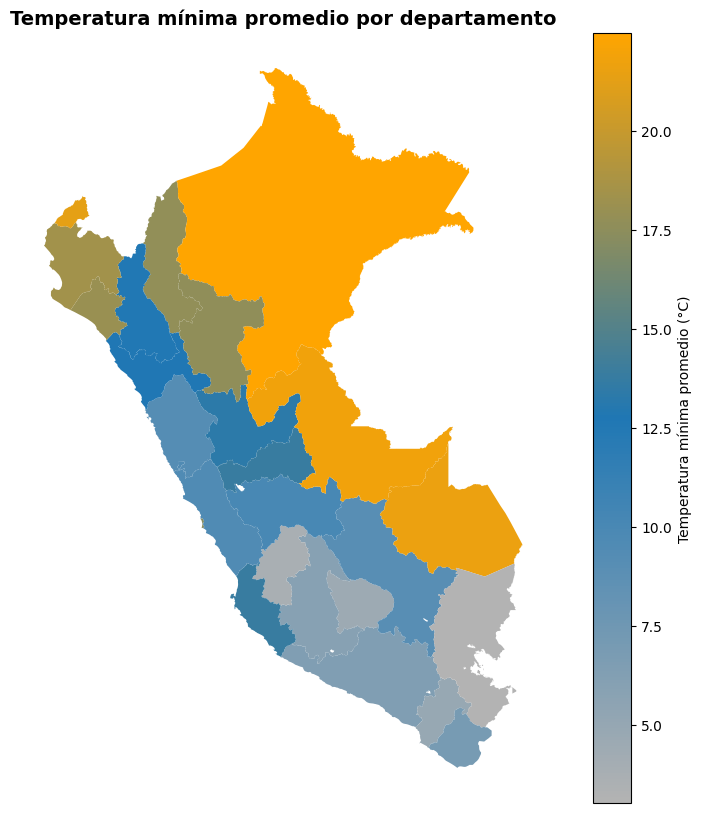


Columnas disponibles en el dataframe:
['CCDD', 'DEPARTAMEN', 'geometry', 'tmin_count_total', 'tmin_mean_total', 'tmin_min_total', 'tmin_max_total', 'tmin_std_total', 'tmin_median_total', 'tmin_percentile_10_total', 'tmin_percentile_90_total', 'tmin_amplitud_total']


In [45]:
# Visualizamos en un mapa a nivel departamental

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
colors = ["#b3b3b3", "#1f77b4", "#ffa500"]  # frío = azul / menos frío = anaranjado
cmap_custom = LinearSegmentedColormap.from_list("FrioAzulNaranja", colors, N=256)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
dept.plot(
    column="tmin_mean_total",    # Variable a graficar
    ax=ax,
    legend=True,
    cmap=cmap_custom,
    legend_kwds={
        'label': "Temperatura mínima promedio (°C)",
        'orientation': 'vertical'
    }
)
ax.set_title("Temperatura mínima promedio por departamento", fontsize=14, fontweight="bold")
ax.axis("off")
plt.show()
print("\nColumnas disponibles en el dataframe:")
print(dept.columns.tolist())

# 3.3 Analysis & visualizations

In [46]:
# Verificar los datos que tenemos
print("Columnas disponibles en dist:")
print(dist.columns.tolist())
print(f"\nTotal de distritos: {len(dist)}")
print(f"Distritos con datos de Tmin: {dist['tmin_mean_total'].notna().sum()}")

# Filtrar distritos con datos válidos para el análisis
dist_validos = dist[dist['tmin_mean_total'].notna()].copy()
print(f"Distritos válidos para análisis: {len(dist_validos)}")

Columnas disponibles en dist:
['UBIGEO', 'CCDD', 'CCPP', 'CCDI', 'DEPARTAMEN', 'PROVINCIA', 'DISTRITO', 'OBJECTID', 'ESRI_OID', 'geometry', 'tmin_count_total', 'tmin_mean_total', 'tmin_min_total', 'tmin_max_total', 'tmin_std_total', 'tmin_median_total', 'tmin_percentile_10_total', 'tmin_percentile_90_total', 'tmin_amplitud_total', 'tiene_dato']

Total de distritos: 1891
Distritos con datos de Tmin: 1805
Distritos válidos para análisis: 1805


### A. DISTRIBUCIÓN: HISTOGRAMA/KDE DE Tmin PROMEDIO

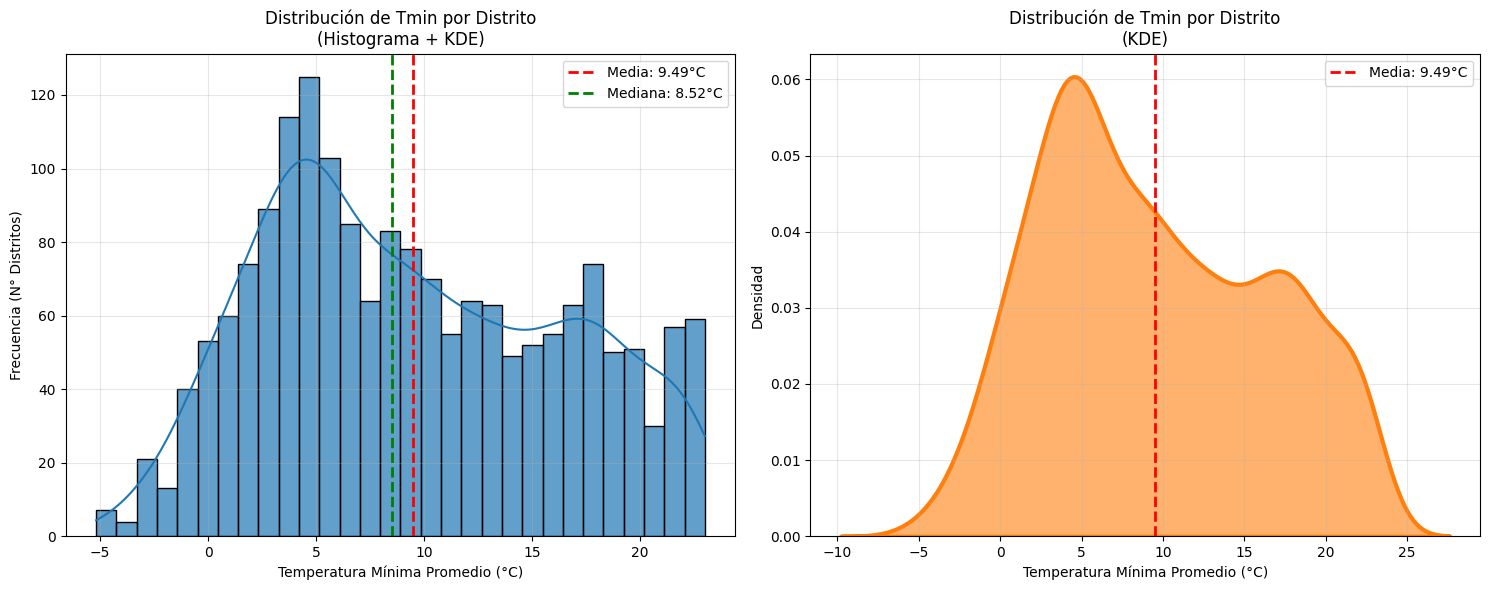

\ESTADÍSTICAS DESCRIPTIVAS - Tmin Promedio:
• Media: 9.49°C
• Mediana: 8.52°C
• Desviación estándar: 6.87°C
• Mínimo: -5.19°C
• Máximo: 23.01°C
• Rango: 28.20°C
• Percentil 10: 1.15°C
• Percentil 90: 19.61°C


In [47]:
import os

# Crear el directorio si no existe
os.makedirs("./data/output", exist_ok=True)

# Crear figura con histograma y KDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histograma con KDE
sns.histplot(data=dist_validos, x='tmin_mean_total', bins=30, kde=True, 
             ax=ax1, color='#1f77b4', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Temperatura Mínima Promedio (°C)')
ax1.set_ylabel('Frecuencia (N° Distritos)')
ax1.set_title('Distribución de Tmin por Distrito\n(Histograma + KDE)')
ax1.grid(alpha=0.3)

# KDE separado
sns.kdeplot(data=dist_validos, x='tmin_mean_total', ax=ax2, 
            linewidth=3, color='#ff7f0e', fill=True, alpha=0.6)
ax2.set_xlabel('Temperatura Mínima Promedio (°C)')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de Tmin por Distrito\n(KDE)')
ax2.grid(alpha=0.3)

mean_temp = dist_validos['tmin_mean_total'].mean()
median_temp = dist_validos['tmin_mean_total'].median()
std_temp = dist_validos['tmin_mean_total'].std()

ax1.axvline(mean_temp, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_temp:.2f}°C')
ax1.axvline(median_temp, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_temp:.2f}°C')
ax1.legend()

ax2.axvline(mean_temp, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_temp:.2f}°C')
ax2.legend()

plt.tight_layout()
plt.savefig("./data/output/3_3_distribution_tmin.png", dpi=300, bbox_inches='tight')
plt.show()

print("\ESTADÍSTICAS DESCRIPTIVAS - Tmin Promedio:")
print(f"• Media: {mean_temp:.2f}°C")
print(f"• Mediana: {median_temp:.2f}°C")
print(f"• Desviación estándar: {std_temp:.2f}°C")
print(f"• Mínimo: {dist_validos['tmin_mean_total'].min():.2f}°C")
print(f"• Máximo: {dist_validos['tmin_mean_total'].max():.2f}°C")
print(f"• Rango: {dist_validos['tmin_mean_total'].max() - dist_validos['tmin_mean_total'].min():.2f}°C")
print(f"• Percentil 10: {dist_validos['tmin_mean_total'].quantile(0.1):.2f}°C")
print(f"• Percentil 90: {dist_validos['tmin_mean_total'].quantile(0.9):.2f}°C")

###### A partir de la gráfica podemos observar que la media de la temperatua es 9.49°C  mayor a la mediana que es 8.52°C lo que significa que existe una ligera distribución a la derecha de manera positiva. Además, nuestra desviación estándar de 6.87°C es un valor alto por lo que significa que las temperaturas se encuentran muy dispersas alrededor de la media y no existe una temperatura minima consistente, es decir, existen alta variabilidad en las condiciones climaticas. 
###### La temperatura mínima promedio se encuentra en el valor -5.19°C y la máxima promedio es de 23.01°C. Esto nos permite confirmar la gran diversidad de condiciones climaticas en nuestro país. 

### RANKING: TOP 15 DE DISTRITOS CON ALTO/BAJO RIESGO DE HELADAS 

In [48]:
# Ordenar por Tmin promedio (más bajas = mayor riesgo de heladas)
df_sorted = dist_validos.sort_values('tmin_mean_total')

# Top 15 más bajas (alto riesgo de heladas)
top15_alto_riesgo = df_sorted.head(15)[['UBIGEO', 'DISTRITO', 'PROVINCIA', 'DEPARTAMEN', 'tmin_mean_total']].copy()
top15_alto_riesgo['riesgo'] = 'Alto Riesgo Heladas'
top15_alto_riesgo['ranking'] = range(1, 16)

# Top 15 más altas (bajo riesgo de heladas)
top15_bajo_riesgo = df_sorted.tail(15)[['UBIGEO', 'DISTRITO', 'PROVINCIA', 'DEPARTAMEN', 'tmin_mean_total']].copy()
top15_bajo_riesgo['riesgo'] = 'Bajo Riesgo Heladas'
top15_bajo_riesgo['ranking'] = range(1, 16)

#### Top 15 distritos con mayor riesgo de heladas

TOP 15 DISTRITOS CON MAYOR RIESGO DE HELADAS


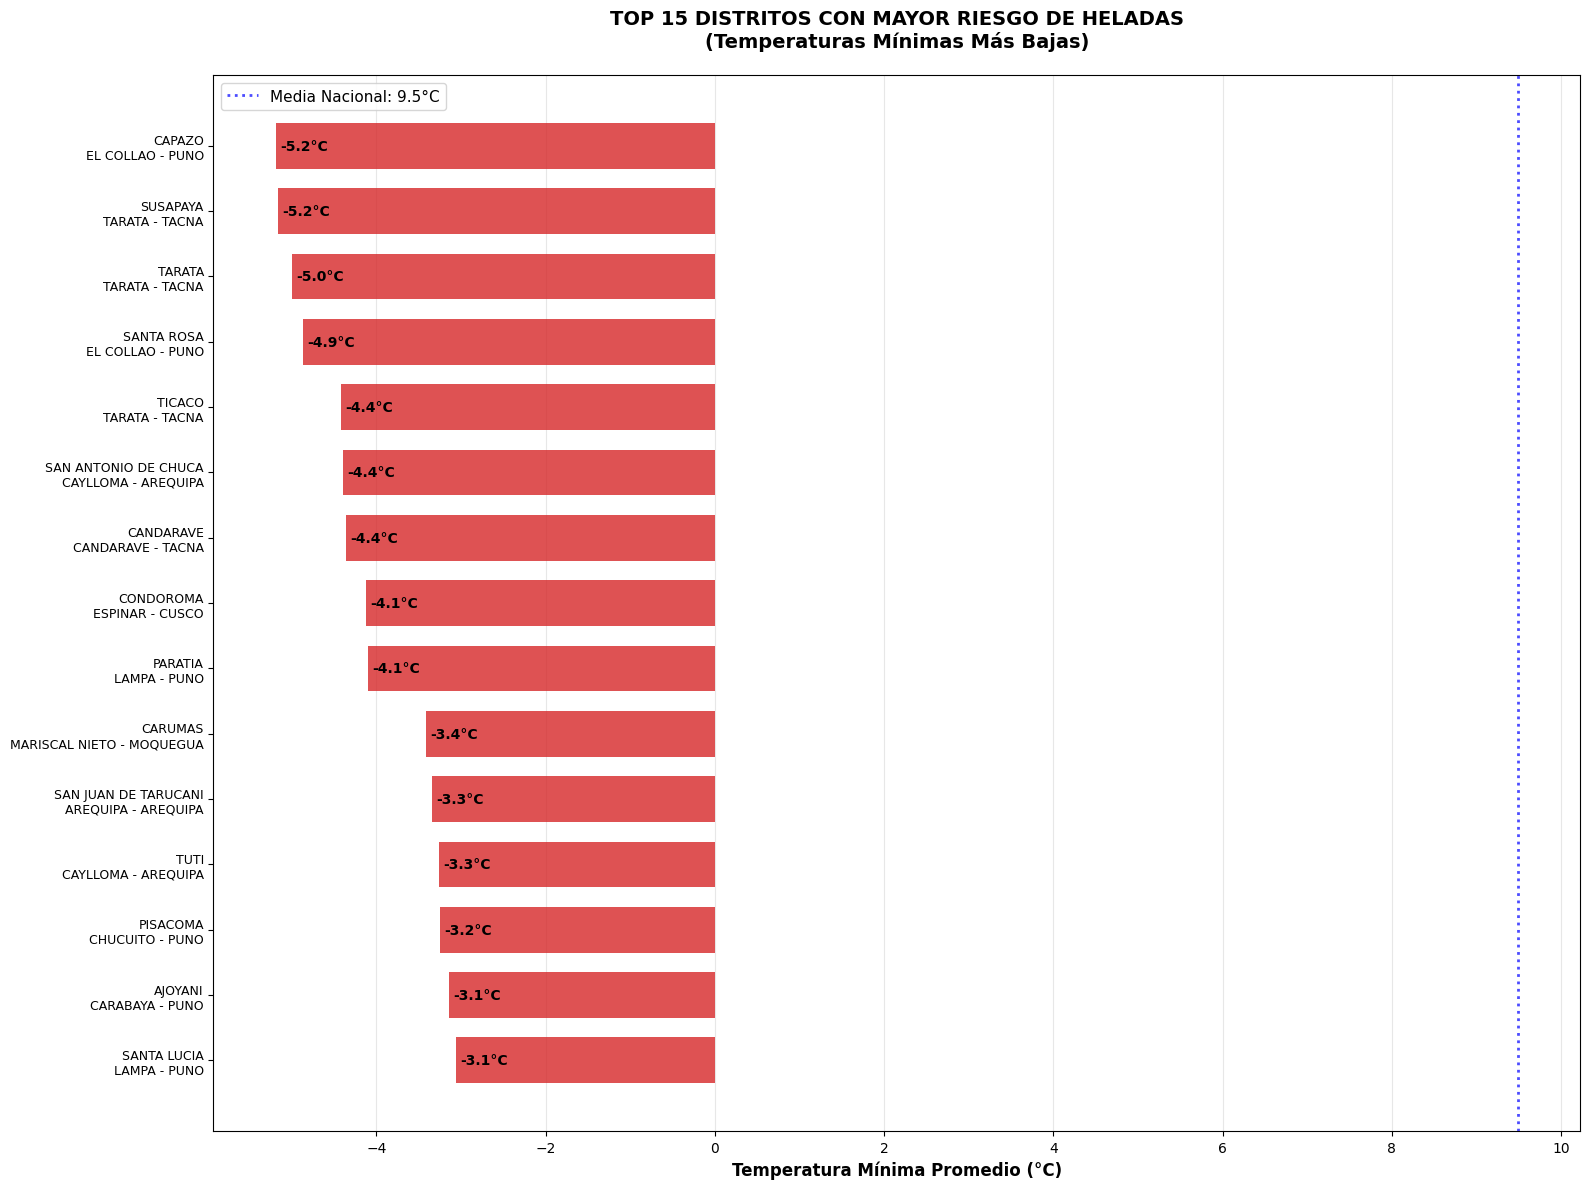

\TOP 15 DISTRITOS CON MAYOR RIESGO DE HELADAS (Tmin más bajas):
 1. CAPAZO               | EL COLLAO       | PUNO            |  -5.2°C
 2. SUSAPAYA             | TARATA          | TACNA           |  -5.2°C
 3. TARATA               | TARATA          | TACNA           |  -5.0°C
 4. SANTA ROSA           | EL COLLAO       | PUNO            |  -4.9°C
 5. TICACO               | TARATA          | TACNA           |  -4.4°C
 6. SAN ANTONIO DE CHUCA | CAYLLOMA        | AREQUIPA        |  -4.4°C
 7. CANDARAVE            | CANDARAVE       | TACNA           |  -4.4°C
 8. CONDOROMA            | ESPINAR         | CUSCO           |  -4.1°C
 9. PARATIA              | LAMPA           | PUNO            |  -4.1°C
10. CARUMAS              | MARISCAL NIETO  | MOQUEGUA        |  -3.4°C
11. SAN JUAN DE TARUCANI | AREQUIPA        | AREQUIPA        |  -3.3°C
12. TUTI                 | CAYLLOMA        | AREQUIPA        |  -3.3°C
13. PISACOMA             | CHUCUITO        | PUNO            |  -3.2°C
14. AJOYANI  

In [49]:
print("TOP 15 DISTRITOS CON MAYOR RIESGO DE HELADAS")

fig1, ax1 = plt.subplots(figsize=(16, 12))

# Ordenar para visualización (de mayor a menor riesgo)
alto_riesgo_plot = top15_alto_riesgo.iloc[::-1]

y_pos = np.arange(len(alto_riesgo_plot))
bars = ax1.barh(y_pos, alto_riesgo_plot['tmin_mean_total'], color='#d62728', alpha=0.8, height=0.7)

ax1.set_yticks(y_pos)
ax1.set_yticklabels([f"{row['DISTRITO']}\n{row['PROVINCIA']} - {row['DEPARTAMEN']}" 
                    for _, row in alto_riesgo_plot.iterrows()], fontsize=9)
ax1.set_xlabel('Temperatura Mínima Promedio (°C)', fontsize=12, fontweight='bold')
ax1.set_title('TOP 15 DISTRITOS CON MAYOR RIESGO DE HELADAS\n(Temperaturas Mínimas Más Bajas)', 
             fontsize=14, fontweight='bold', pad=20)

# Añadir valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 0.05, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}°C', ha='left', va='center', fontsize=10, fontweight='bold')

ax1.axvline(mean_temp, color='blue', linestyle=':', linewidth=2, alpha=0.7, 
           label=f'Media Nacional: {mean_temp:.1f}°C')
ax1.legend(fontsize=11)
ax1.grid(axis='x', alpha=0.3)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.savefig("./data/output/3_3_top15_alto_riesgo.png", dpi=300, bbox_inches='tight')
plt.show()

# Mostrar tabla en consola
print("\TOP 15 DISTRITOS CON MAYOR RIESGO DE HELADAS (Tmin más bajas):")
print("=" * 90)
for i, (idx, row) in enumerate(top15_alto_riesgo.iterrows(), 1):
    print(f"{i:2d}. {row['DISTRITO'][:20]:20} | {row['PROVINCIA'][:15]:15} | {row['DEPARTAMEN'][:15]:15} | {row['tmin_mean_total']:5.1f}°C")
top15_alto_riesgo.to_csv("./data/output/3_3_top15_alto_riesgo.csv", index=False, encoding='utf-8-sig')


#### Top 15 distritos con menor riesgo de heladas

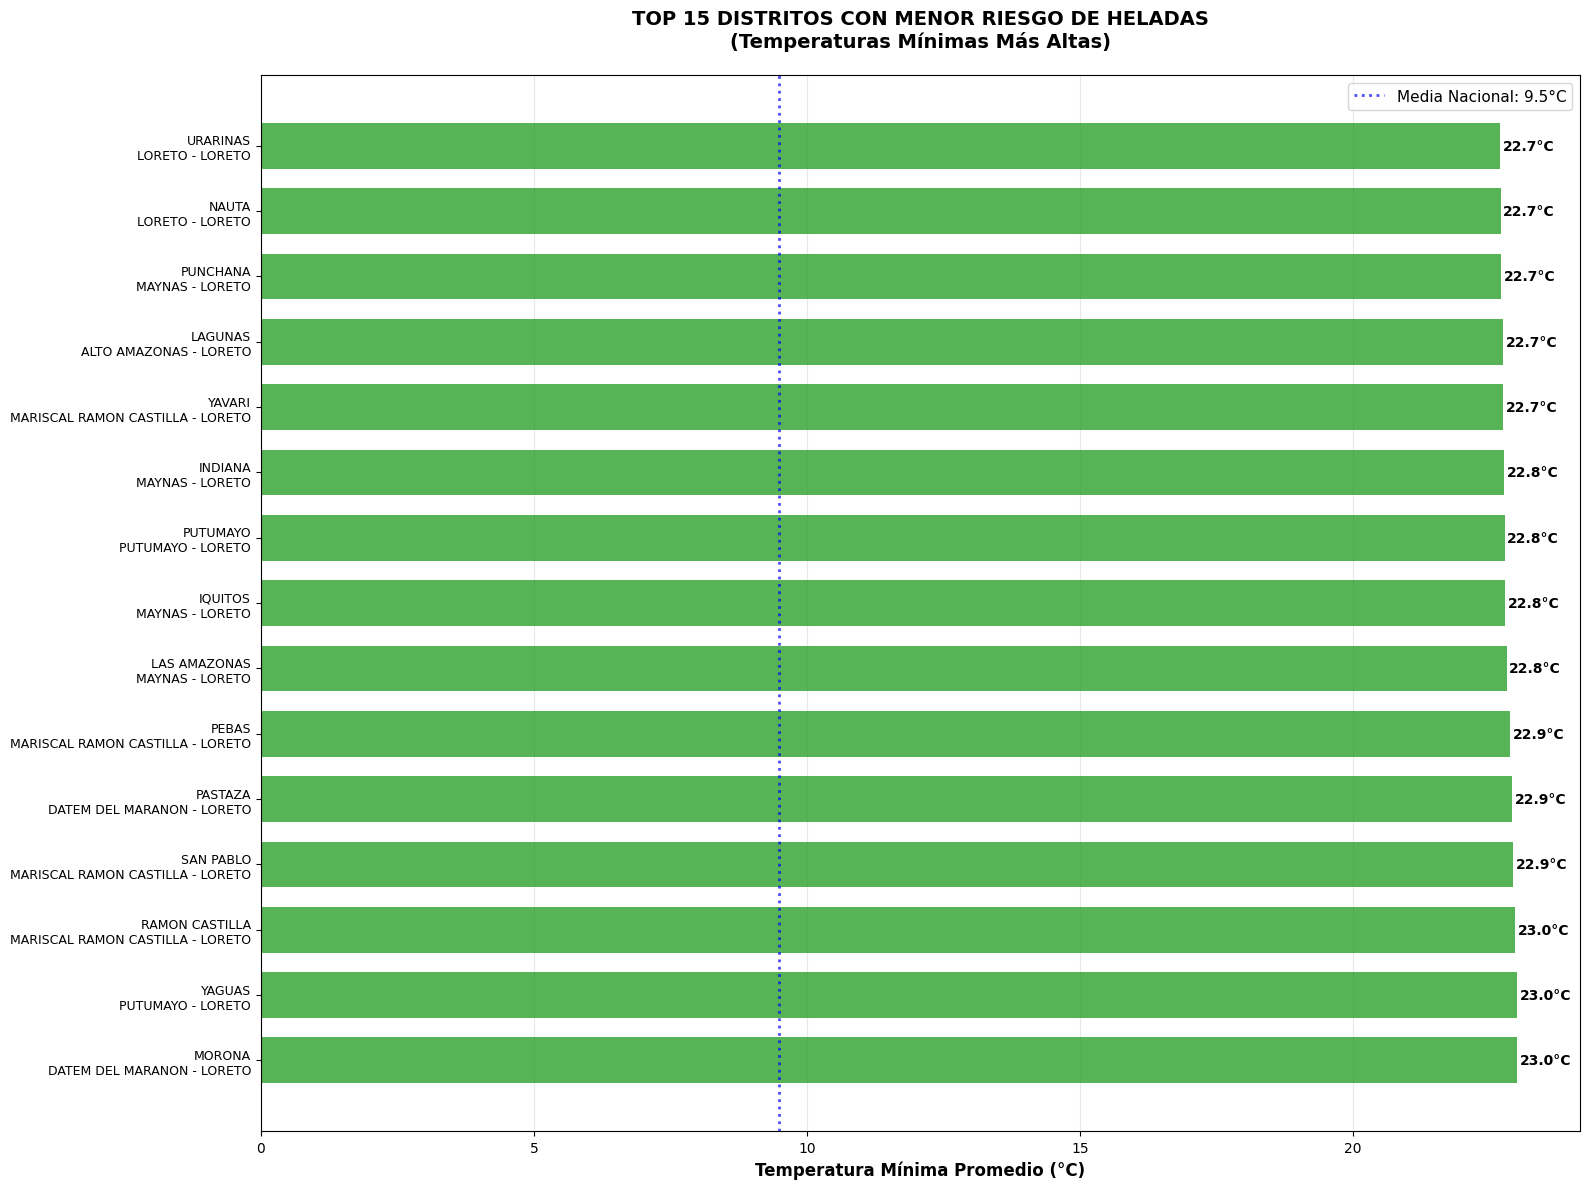

TOP 15 DISTRITOS CON MENOR RIESGO DE HELADAS (Tmin más altas):
 1. URARINAS                  | LORETO               |  22.7°C
 2. NAUTA                     | LORETO               |  22.7°C
 3. PUNCHANA                  | MAYNAS               |  22.7°C
 4. LAGUNAS                   | ALTO AMAZONAS        |  22.7°C
 5. YAVARI                    | MARISCAL RAMON CASTI |  22.7°C
 6. INDIANA                   | MAYNAS               |  22.8°C
 7. PUTUMAYO                  | PUTUMAYO             |  22.8°C
 8. IQUITOS                   | MAYNAS               |  22.8°C
 9. LAS AMAZONAS              | MAYNAS               |  22.8°C
10. PEBAS                     | MARISCAL RAMON CASTI |  22.9°C
11. PASTAZA                   | DATEM DEL MARANON    |  22.9°C
12. SAN PABLO                 | MARISCAL RAMON CASTI |  22.9°C
13. RAMON CASTILLA            | MARISCAL RAMON CASTI |  23.0°C
14. YAGUAS                    | PUTUMAYO             |  23.0°C
15. MORONA                    | DATEM DEL MARANON    | 

In [50]:
fig2, ax2 = plt.subplots(figsize=(16, 12))

# Ordenar para visualización (de menor a mayor temperatura)
bajo_riesgo_plot = top15_bajo_riesgo.iloc[::-1]  # Invertir para mostrar de menor a mayor

y_pos = np.arange(len(bajo_riesgo_plot))
bars = ax2.barh(y_pos, bajo_riesgo_plot['tmin_mean_total'], color='#2ca02c', alpha=0.8, height=0.7)

ax2.set_yticks(y_pos)
ax2.set_yticklabels([f"{row['DISTRITO']}\n{row['PROVINCIA']} - {row['DEPARTAMEN']}" 
                    for _, row in bajo_riesgo_plot.iterrows()], fontsize=9)

ax2.set_xlabel('Temperatura Mínima Promedio (°C)', fontsize=12, fontweight='bold')
ax2.set_title('TOP 15 DISTRITOS CON MENOR RIESGO DE HELADAS\n(Temperaturas Mínimas Más Altas)', 
             fontsize=14, fontweight='bold', pad=20)

# Añadir valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 0.05, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}°C', ha='left', va='center', fontsize=10, fontweight='bold')

ax2.axvline(mean_temp, color='blue', linestyle=':', linewidth=2, alpha=0.7, 
           label=f'Media Nacional: {mean_temp:.1f}°C')
ax2.legend(fontsize=11)
ax2.grid(axis='x', alpha=0.3)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig("./data/output/3_3_top15_bajo_riesgo.png", dpi=300, bbox_inches='tight')
plt.show()

# Mostrar tabla en consola
print("TOP 15 DISTRITOS CON MENOR RIESGO DE HELADAS (Tmin más altas):")
print("=" * 70)
for i, (idx, row) in enumerate(top15_bajo_riesgo.iterrows(), 1):
    print(f"{i:2d}. {row['DISTRITO'][:25]:25} | {row['PROVINCIA'][:20]:20} | {row['tmin_mean_total']:5.1f}°C")

top15_bajo_riesgo.to_csv("./data/output/3_3_top15_bajo_riesgo.csv", index=False, encoding='utf-8-sig')

## C. MAPA COROPLÉTICO ESTÁTICO

C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\3986334427.py:41: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = distrito_data.geometry.centroid.iloc[0]
C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\3986334427.py:41: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = distrito_data.geometry.centroid.iloc[0]
C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\3986334427.py:41: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = distrito_data.geometry.centroid.iloc[0]
C:\Users\KikeMa\AppData\Local\Temp\ipykernel_21440\3986334427.py:41: UserWarnin

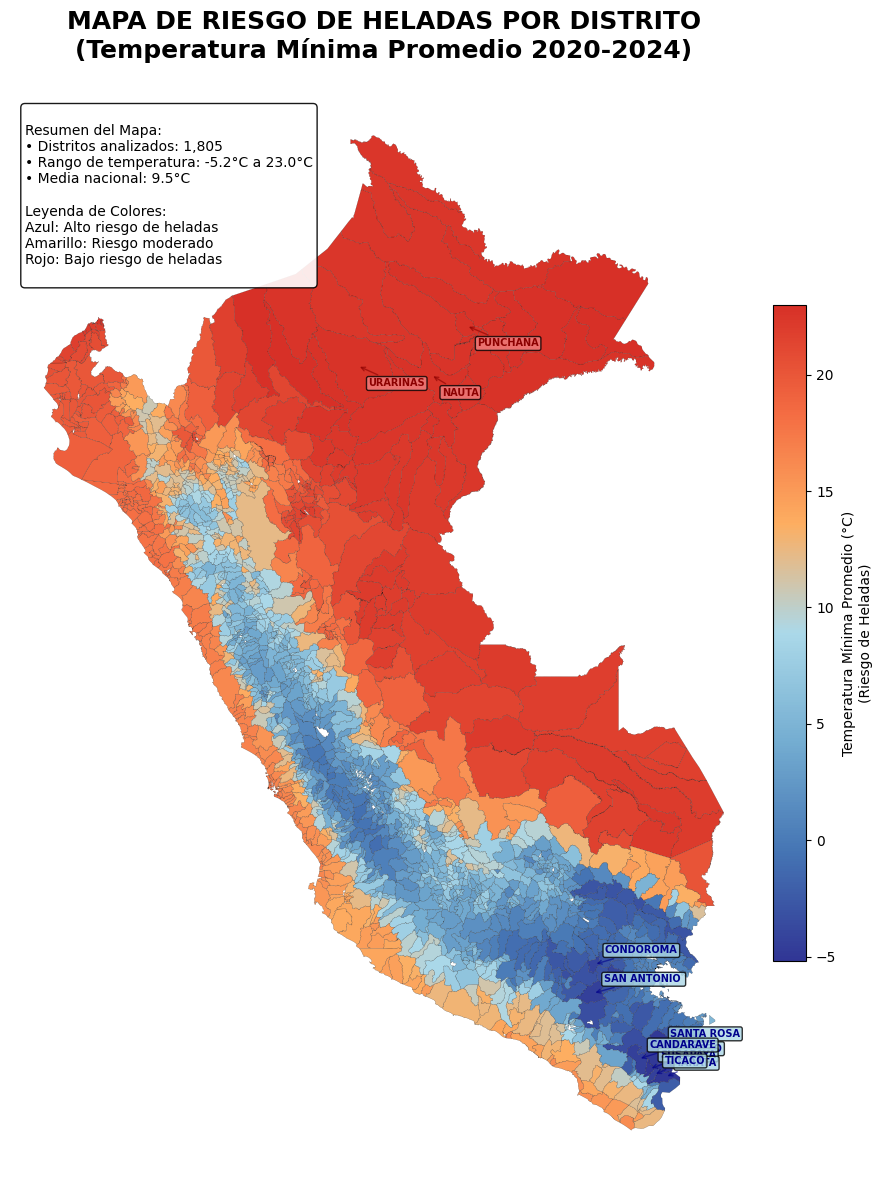

In [51]:
# Configurar colores para riesgo de heladas (escala divergente: azul=frío, rojo=cálido)
colors = ["#313695", "#4575b4", "#74add1", "#abd9e9", "#fdae61", "#f46d43", "#d73027"]
cmap_riesgo = LinearSegmentedColormap.from_list("RiesgoHeladas", colors, N=256)

# Crear figura para el mapa
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

# Determinar rangos para la leyenda
vmin = dist_validos['tmin_mean_total'].min()
vmax = dist_validos['tmin_mean_total'].max()

# Plot del mapa coroplético
dist_validos.plot(column='tmin_mean_total', 
                  ax=ax, 
                  legend=True,
                  cmap=cmap_riesgo,
                  edgecolor='black',
                  linewidth=0.1,
                  vmin=vmin,
                  vmax=vmax,
                  missing_kwds={
                      'color': 'lightgrey', 
                      'label': 'Sin datos',
                      'hatch': '///'
                  },
                  legend_kwds={
                      'label': 'Temperatura Mínima Promedio (°C)\n(Riesgo de Heladas)',
                      'orientation': 'vertical',
                      'shrink': 0.6,
                      'aspect': 20,
                      'pad': 0.01
                  })

ax.set_title('MAPA DE RIESGO DE HELADAS POR DISTRITO\n(Temperatura Mínima Promedio 2020-2024)', 
             fontsize=18, fontweight='bold', pad=20)

# Añadir anotaciones para los distritos de extremo riesgo
for idx, row in top15_alto_riesgo.head(8).iterrows():
    distrito_data = dist_validos[dist_validos['UBIGEO'] == row['UBIGEO']]
    if not distrito_data.empty:
        centroid = distrito_data.geometry.centroid.iloc[0]
        ax.annotate(f"{row['DISTRITO'][:12]}", 
                   xy=(centroid.x, centroid.y), 
                   xytext=(8, 8), textcoords="offset points",
                   fontsize=7, color='darkblue', weight='bold',
                   bbox=dict(boxstyle="round,pad=0.2", facecolor="lightblue", alpha=0.8),
                   arrowprops=dict(arrowstyle="->", color="darkblue", alpha=0.6))

for idx, row in top15_bajo_riesgo.head(3).iterrows():
    distrito_data = dist_validos[dist_validos['UBIGEO'] == row['UBIGEO']]
    if not distrito_data.empty:
        centroid = distrito_data.geometry.centroid.iloc[0]
        ax.annotate(f"{row['DISTRITO'][:12]}", 
                   xy=(centroid.x, centroid.y), 
                   xytext=(8, -15), textcoords="offset points",
                   fontsize=7, color='darkred', weight='bold',
                   bbox=dict(boxstyle="round,pad=0.2", facecolor="lightcoral", alpha=0.8),
                   arrowprops=dict(arrowstyle="->", color="darkred", alpha=0.6))

ax.set_axis_off()

# Añadir cuadro de información
info_text = f"""
Resumen del Mapa:
• Distritos analizados: {len(dist_validos):,}
• Rango de temperatura: {vmin:.1f}°C a {vmax:.1f}°C
• Media nacional: {mean_temp:.1f}°C

Leyenda de Colores:
Azul: Alto riesgo de heladas
Amarillo: Riesgo moderado  
Rojo: Bajo riesgo de heladas
"""
ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.savefig("./data/output/3_3_choropleth_riesgo_heladas.png", dpi=300, bbox_inches='tight')
plt.show()

## Guardamos la información creada

In [52]:
# Crear directorio de output si no existe
os.makedirs("./data/output", exist_ok=True)

# 1. Tabla completa de resultados
df_export_completo = dist_validos[['UBIGEO', 'DISTRITO', 'PROVINCIA', 'DEPARTAMEN', 
                                  'tmin_mean_total', 'tmin_min_total', 'tmin_max_total',
                                  'tmin_std_total', 'tmin_median_total', 
                                  'tmin_percentile_10_total', 'tmin_percentile_90_total',
                                  'tmin_amplitud_total']].copy()

# Renombrar columnas para mejor comprensión
df_export_completo = df_export_completo.rename(columns={
    'tmin_mean_total': 'tmin_promedio',
    'tmin_min_total': 'tmin_minima',
    'tmin_max_total': 'tmin_maxima', 
    'tmin_std_total': 'tmin_desviacion_estandar',
    'tmin_median_total': 'tmin_mediana',
    'tmin_percentile_10_total': 'tmin_percentil_10',
    'tmin_percentile_90_total': 'tmin_percentil_90',
    'tmin_amplitud_total': 'tmin_amplitud_termica'
})

# 2. Tabla de ranking consolidada
df_ranking_export = pd.concat([top15_alto_riesgo, top15_bajo_riesgo])

# 3. Exportar archivos
df_export_completo.to_csv("./data/output/3_3_tabla_completa_riesgo_heladas.csv", 
                         index=False, encoding='utf-8-sig')

df_ranking_export.to_csv("./data/output/3_3_ranking_riesgo_heladas.csv", 
                        index=False, encoding='utf-8-sig')

# 4. Exportar GeoJSON para aplicaciones web
dist_validos.to_file("./data/output/3_3_distritos_riesgo_heladas.geojson", 
                    driver='GeoJSON', encoding='utf-8')